# EFS-01 resource addendum practice

This companion notebook adds the official-resource mechanics that sit around the main EFS-01 practice notebook: Excel-style parameter tables, assignment outputs, derivative quadrant interpretation, delivery-volume factor use, FAQ implementation cautions, and the expiry-day VWAP/cash-unwind setup from the workbook.

## Setup

Load the Nifty daily series and the addendum tables generated from the official resources.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

root = Path(".")
nifty = pd.read_csv(root / "nifty_daily.csv", parse_dates=["Date"])
param = pd.read_csv(root / "efs01_parameter_surface.csv")
assignment = pd.read_csv(root / "efs01_assignment_metric_checklist.csv")
rules = pd.read_csv(root / "efs01_derivative_signal_rules.csv")
expiry = pd.read_csv(root / "efs01_expiry_vwap_setup.csv", parse_dates=["Date", "Expiry"])
print(f"loaded {len(nifty)} Nifty rows, {len(param)} parameter rows, {len(expiry)} expiry rows")

loaded 4235 Nifty rows, 48 parameter rows, 38 expiry rows


## 1. Excel data-table idea in Python

The lecture and assignment emphasize dynamic worksheets: when SMA/LMA inputs change, the whole backtest should update. The chart below is the Python equivalent of the Excel data table used to scan parameter combinations.

In [2]:
heat = param.pivot(index="SMA", columns="LMA", values="CAGR") * 100
fig, ax = plt.subplots(figsize=(8.8, 4.6))
im = ax.imshow(heat.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(np.arange(len(heat.columns))); ax.set_xticklabels(heat.columns)
ax.set_yticks(np.arange(len(heat.index))); ax.set_yticklabels(heat.index)
ax.set_xlabel("Long moving average (LMA)"); ax.set_ylabel("Short moving average (SMA)")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
best = param.loc[param["CAGR"].idxmax()]
ax.scatter([list(heat.columns).index(best["LMA"])], [list(heat.index).index(best["SMA"])], s=260, facecolors="none", edgecolors="black", linewidths=2)
ax.set_title("SMA/LMA parameter surface (CAGR %)")
fig.colorbar(im, ax=ax, label="CAGR %")
fig.tight_layout()
plt.savefig("chart_addendum_1_efs01_parameter_surface.png", dpi=140, bbox_inches="tight")
plt.show()

best.to_frame().T

C:\Users\hsaeed\AppData\Local\Temp\1\ipykernel_26004\1714376358.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,SMA,LMA,CAGR
4,3.0,50.0,0.12265


## 2. Assignment checklist

The assignment switches the crossover from SMA to EMA and asks for more than one summary number. These outputs make the model auditable by performance, risk, leverage, and year-wise stability.

In [3]:
assignment

,output,definition,why_it_matters
0,CAGR,Compound annual growth rate for the EMA crosso...,Performance scale
1,Hit ratio,Profitable trades divided by total trades,Trade success rate
2,Average profit per trade,Mean return on winning trades,Win size
3,Average loss per trade,Mean return on losing trades,Loss size
4,Profit/loss ratio,Average profit divided by average loss,Payoff asymmetry
5,Maximum drawdown,Largest peak-to-trough equity decline at lever...,Capital pain
6,Leveraged equity curves,"Equity curves for leverage 1, 2, 3, and 4",Leverage fragility
7,Year-wise long profit,Calendar-year profit from long trades,Regime diagnosis
8,Year-wise short profit,Calendar-year profit from short trades,Regime diagnosis
9,Year-wise hit ratio,Annual hit ratio,Stability check


## 3. Derivative quadrant rules

The lecture summary gives separate interpretation maps for price with open interest and price with cost of carry. These are directional diagnostics, not standalone trade signals.

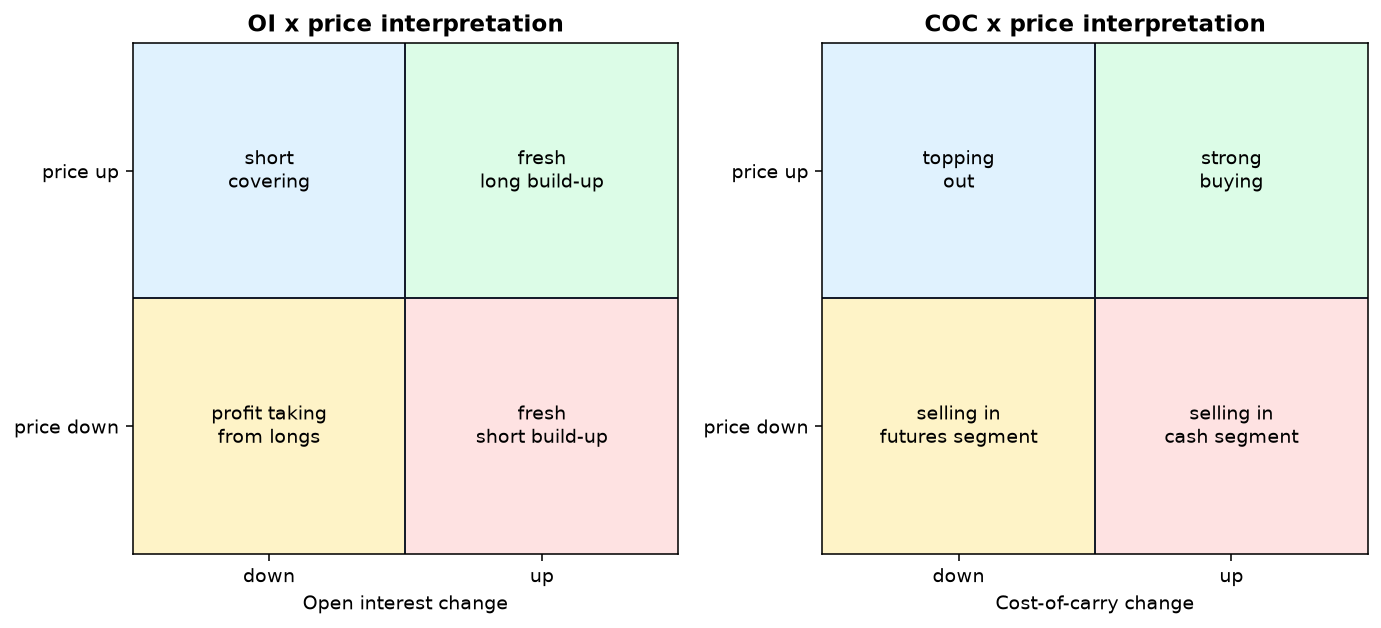

,condition,interpretation,implementation_note
0,"OI up, price up",Fresh long build-up,Trend confirmation from new longs
1,"OI up, price down",Fresh short build-up,Bearish pressure from new shorts
2,"OI down, price up",Short covering,Rally may be driven by shorts exiting
3,"OI down, price down",Profit taking from longs,Weakness may be longs exiting
4,"COC up, price up",Strong buying,Futures premium confirms demand
5,"COC up, price down",Selling in cash segment,Cash selling while futures premium remains ele...
6,"COC down, price up",Topping out,Price rises while futures premium weakens
7,"COC down, price down",Selling in futures segment,Futures selling confirms weakness


In [4]:
display(Image(filename="chart_addendum_2_efs01_derivative_quadrants.png"))
rules.head(8)

## 4. Expiry-day VWAP/cash-unwind setup

The in-class VWAP note describes cash-future arbitrage inventory being unwound near expiry. The workbook data tracks cost of carry and open interest into expiry for TATACHEM and MARUTI.

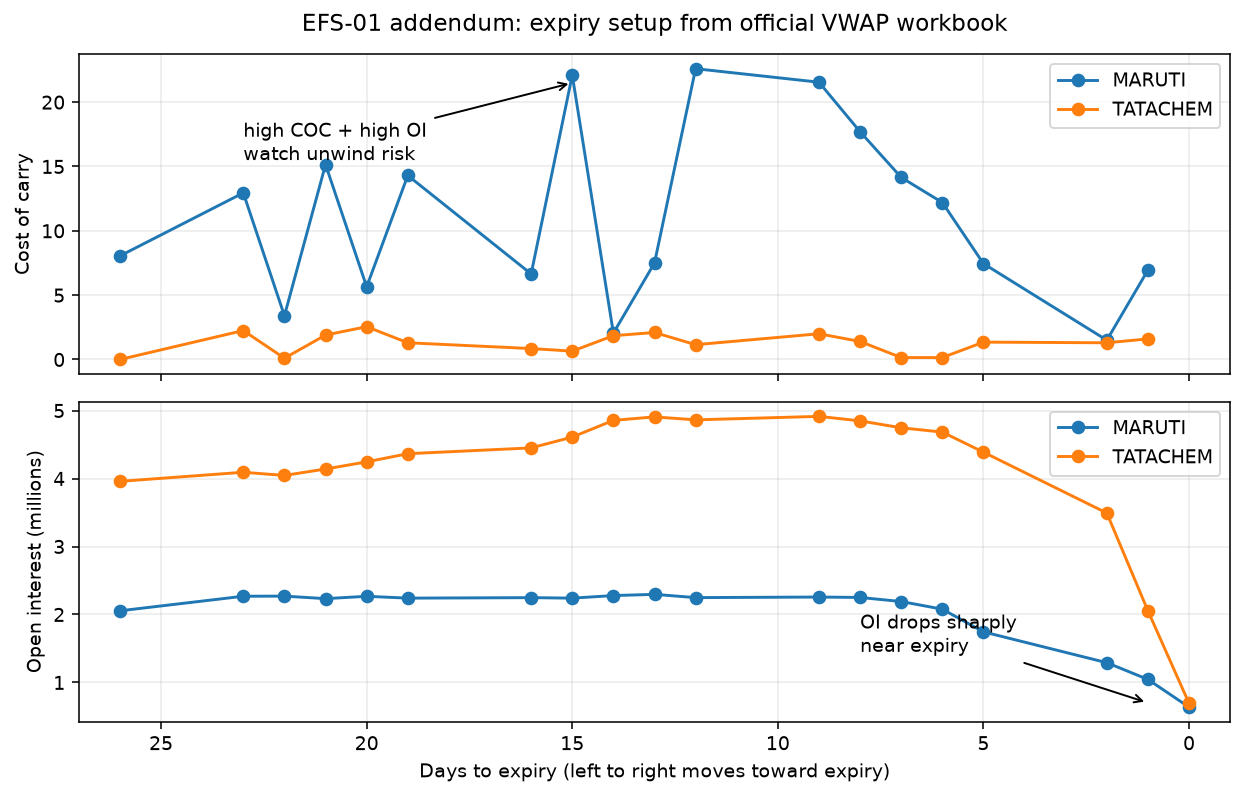

,Symbol,Date,Expiry,days_to_expiry,Close,Underlying Value,Open Int,Change in OI,CoC
23,MARUTI,2017-01-05,2017-01-25,20,5640.60,5634.95,2267550.0,34500.0,5.65
22,MARUTI,2017-01-04,2017-01-25,21,5517.30,5502.15,2233050.0,-37050.0,15.15
21,MARUTI,2017-01-03,2017-01-25,22,5511.80,5508.40,2270100.0,1650.0,3.40
20,MARUTI,2017-01-02,2017-01-25,23,5478.95,5466.00,2268450.0,214200.0,12.95
19,MARUTI,2016-12-30,2017-01-25,26,5327.60,5319.55,2054250.0,27000.0,8.05
4,TATACHEM,2017-01-05,2017-01-25,20,510.70,508.15,4245000.0,105000.0,2.55
3,TATACHEM,2017-01-04,2017-01-25,21,507.00,505.10,4140000.0,94500.0,1.90
2,TATACHEM,2017-01-03,2017-01-25,22,509.85,509.75,4045500.0,-46500.0,0.10
1,TATACHEM,2017-01-02,2017-01-25,23,509.20,506.95,4092000.0,133500.0,2.25
0,TATACHEM,2016-12-30,2017-01-25,26,503.00,503.00,3958500.0,328500.0,0.00


In [5]:
display(Image(filename="chart_addendum_3_efs01_expiry_vwap_setup.png"))
expiry.sort_values(["Symbol", "days_to_expiry"]).groupby("Symbol").tail(5)

## 5. FAQ implementation cautions

The FAQ closes several common loopholes: slippage must be included, volume may be reported as shares or lots depending on provider, all major regimes should be represented, and discretionary averaging is not valid unless it was part of the tested rules.

In [6]:
rules.tail(5)

,condition,interpretation,implementation_note
8,Delivery volume above its SMA,Delivery participation is meaningful,"Use with OI and price change, not alone"
9,High OI and high COC near expiry,Potential cash unwind pressure,Candidate for expiry-day short-cash setup
10,Sharpe >= 2,Good strategy quality,"FAQ says 2+ good, 3+ excellent"
11,Live results deviate from tested regime,Diagnose regime mismatch,Compare current market regime to backtest regimes
12,Averaging loser not in rules,Avoid discretionary averaging,Systematic strategy should follow tested rules


## Addendum summary

The original notebook evaluates a moving-average strategy. This addendum adds the official workflow around it: dynamic parameter search, assignment-level metrics, derivative data interpretation, expiry setup analysis, and live-risk cautions.